#Airbnb helps people to stay and let homeowners to rent out their spaces. This dataset shows whole information about airbnb listing in New york 2019.

In [ ]:
# Importing libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import warnings
warnings.filterwarnings('ignore')

# this tells python to hide or ignore all the warning message when code executes.

In [6]:
df = pd.read_csv('/content/AB_NYC_2019.csv')

In [7]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [8]:
# see all the column names

df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [9]:
renameColList = {
    'id' : 'Property_id',
    'name' : 'Poperty_name',
    'number_of_reviews' : 'total_reviews',
    'calculated_host_listings_count' : 'host_listing_count'

}

In [10]:
df = df.rename(columns=renameColList) #inplace=True

In [11]:
df

,Property_id,Poperty_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_reviews,last_review,reviews_per_month,host_listing_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [12]:
# shape inspection

x = df.shape
print(f"The no of rows :{x[0]} and no of columns {x[1]}")

# f-string : formatting the string

The no of rows :48895 and no of columns 16


In [13]:
# information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Property_id          48895 non-null  int64  
 1   Poperty_name         48879 non-null  object 
 2   host_id              48895 non-null  int64  
 3   host_name            48874 non-null  object 
 4   neighbourhood_group  48895 non-null  object 
 5   neighbourhood        48895 non-null  object 
 6   latitude             48895 non-null  float64
 7   longitude            48895 non-null  float64
 8   room_type            48895 non-null  object 
 9   price                48895 non-null  int64  
 10  minimum_nights       48895 non-null  int64  
 11  total_reviews        48895 non-null  int64  
 12  last_review          38843 non-null  object 
 13  reviews_per_month    38843 non-null  float64
 14  host_listing_count   48895 non-null  int64  
 15  availability_365     48895 non-null 

*Insights*

sum columns are having null values

In [14]:
df.head()

,Property_id,Poperty_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_reviews,last_review,reviews_per_month,host_listing_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [15]:
df.last_review

,last_review
0,2018-10-19
1,2019-05-21
2,NaN
3,2019-07-05
4,2018-11-19
...,...
48890,NaN
48891,NaN
48892,NaN
48893,NaN


In [16]:
# dropping my last review column

df.drop('last_review', axis =1, inplace=True)

# axis =1 -- direction
# axis =0



In [17]:
df

,Property_id,Poperty_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_reviews,reviews_per_month,host_listing_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,6,2


In [18]:
# checking duplicate row

df.duplicated().sum()

np.int64(0)

In [19]:
# checking null values

df.isnull().sum()

,0
Property_id,0
Poperty_name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# dealing with null values

# drop: huge data and null values are very less than
# replace: less data and null values are present



In [20]:
df.shape

# attribute

(48895, 15)

In [21]:
df.Poperty_name

,Poperty_name
0,Clean & quiet apt home by the park
1,Skylit Midtown Castle
2,THE VILLAGE OF HARLEM....NEW YORK !
3,Cozy Entire Floor of Brownstone
4,Entire Apt: Spacious Studio/Loft by central park
...,...
48890,Charming one bedroom - newly renovated rowhouse
48891,Affordable room in Bushwick/East Williamsburg
48892,Sunny Studio at Historical Neighborhood
48893,43rd St. Time Square-cozy single bed


In [22]:
df.Poperty_name.dtype

# In pandas, string datatypes is Objects

dtype('O')

In [23]:
# we are replacing the values with Unknown

df['Poperty_name'].fillna('Unknown', inplace=True)

In [24]:
df.Poperty_name.isnull().sum()

np.int64(0)

In [25]:
df.host_name

,host_name
0,John
1,Jennifer
2,Elisabeth
3,LisaRoxanne
4,Laura
...,...
48890,Sabrina
48891,Marisol
48892,Ilgar & Aysel
48893,Taz


In [26]:
df.host_name.dtype

dtype('O')

In [27]:
df['host_name'].fillna('Unknown', inplace=True)

In [28]:
df.host_name.isnull().sum()

np.int64(0)

In [29]:
df.reviews_per_month

,reviews_per_month
0,0.21
1,0.38
2,NaN
3,4.64
4,0.10
...,...
48890,NaN
48891,NaN
48892,NaN
48893,NaN


In [30]:
df.reviews_per_month.dtype

dtype('float64')

In [31]:
df.reviews_per_month = df.reviews_per_month.replace(to_replace=np.nan, value=0).astype('int64')

In [32]:
df.isnull().sum()

,0
Property_id,0
Poperty_name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# basic understanding about dataset

# how many unique properties we are having in this new york

a = df.property_id.nunique()

print(f"The toytal unique property in new york city is {a}")

In [33]:
# how many neighbourhood we are having

a = df.neighbourhood.nunique()

print(f"The total number of neighbours in the new york city {a}")

The total number of neighbours in the new york city 221


In [34]:
# total neighbourhood group

a = df.neighbourhood_group.nunique()

print(f"The total neighbourhood gropu in the new york city is {a}")

The total neighbourhood gropu in the new york city is 5


In [35]:
# how many host are there?

a = df.host_name.nunique()

print(f"The total host available in new york city {a}")

The total host available in new york city 11453


In [36]:
# total properties

a = df.Poperty_name.nunique()

print(f"The total properties available in nyc {a}")

The total properties available in nyc 47906


In [38]:
#

pd.set_option('display.float_format', '{:.2f}'.format)

Statistical summary




In [39]:
df.describe()

,Property_id,host_id,latitude,longitude,price,minimum_nights,total_reviews,reviews_per_month,host_listing_count,availability_365
count,48895.00,48895.00,48895.00,48895.00,48895.00,48895.00,48895.00,48895.00,48895.00,48895.00
mean,19017143.24,67620010.65,40.73,-73.95,152.72,7.03,23.27,0.81,7.14,112.78
std,10983108.39,78610967.03,0.05,0.05,240.15,20.51,44.55,1.50,32.95,131.62
min,2539.00,2438.00,40.50,-74.24,0.00,1.00,0.00,0.00,1.00,0.00
25%,9471945.00,7822033.00,40.69,-73.98,69.00,1.00,1.00,0.00,1.00,0.00
50%,19677284.00,30793816.00,40.72,-73.96,106.00,3.00,5.00,0.00,1.00,45.00
75%,29152178.50,107434423.00,40.76,-73.94,175.00,5.00,24.00,1.00,2.00,227.00
max,36487245.00,274321313.00,40.91,-73.71,10000.00,1250.00,629.00,58.00,327.00,365.00


#Insights
#the minimum night the person can spend is 1.
#the maximum price is almost around 10k.
#the average availabity is for 112 days.

# visualize the price distribution




<Figure size 1200x500 with 0 Axes>

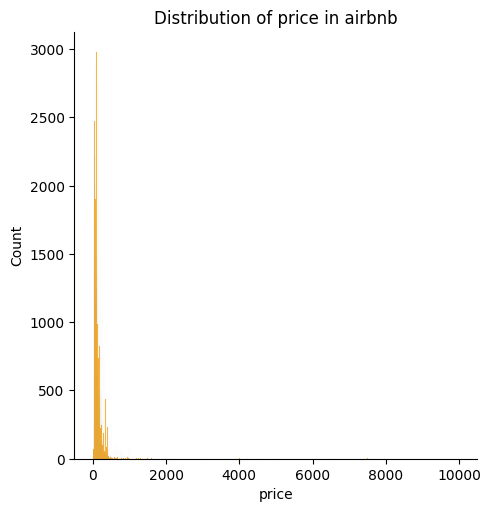

In [41]:
plt.figure(figsize=(12, 5))
sns.displot(df['price'], color = 'orange')
plt.title("Distribution of price in airbnb")
plt.show()

Text(0.5, 1.0, 'The busiest large area')

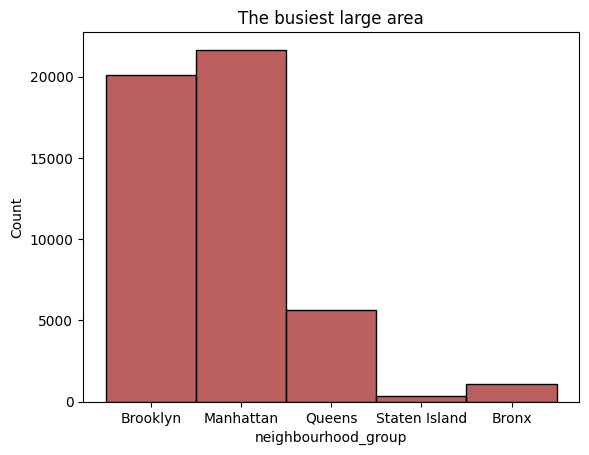

In [46]:
# most busiest neighbourhood group

#sns.barplot(x='neighbourhood_group', hue = 'neighbourhood_group', data=df, color='Brown')

#sns.barplot(df['neighbourhood_group'], color='Brown')

sns.histplot(df['neighbourhood_group'], color='Brown')

plt.title("The busiest large area")

#Price analysis based on neighbourhood group

In [49]:
avg_price = df.groupby('neighbourhood_group', as_index=False)['price'].mean()

In [50]:
avg_price

,neighbourhood_group,price
0,Bronx,87.50
1,Brooklyn,124.38
2,Manhattan,196.88
3,Queens,99.52
4,Staten Island,114.81


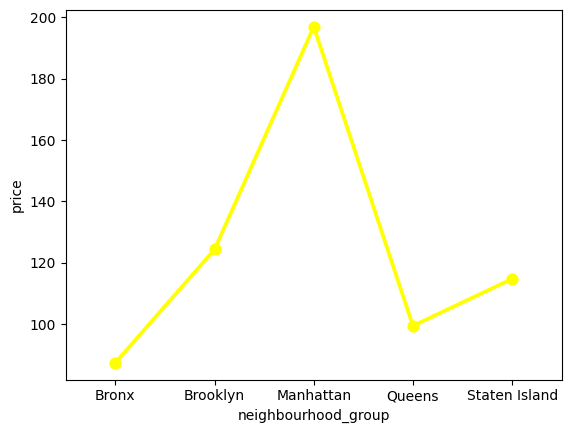

In [51]:
sns.pointplot(x='neighbourhood_group', y='price', data=avg_price, color='yellow')
plt.show()

In [53]:
# top hosts with more listings/properties using bar plot

top_10_hosts = df['host_name'].value_counts()[:10].reset_index()
top_10_hosts

,host_name,count
0,Michael,417
1,David,403
2,Sonder (NYC),327
3,John,294
4,Alex,279
5,Blueground,232
6,Sarah,227
7,Daniel,226
8,Jessica,205
9,Maria,204


In [54]:
top_10_hosts.columns=['host_name', 'total_listing']

In [55]:
top_10_hosts

,host_name,total_listing
0,Michael,417
1,David,403
2,Sonder (NYC),327
3,John,294
4,Alex,279
5,Blueground,232
6,Sarah,227
7,Daniel,226
8,Jessica,205
9,Maria,204


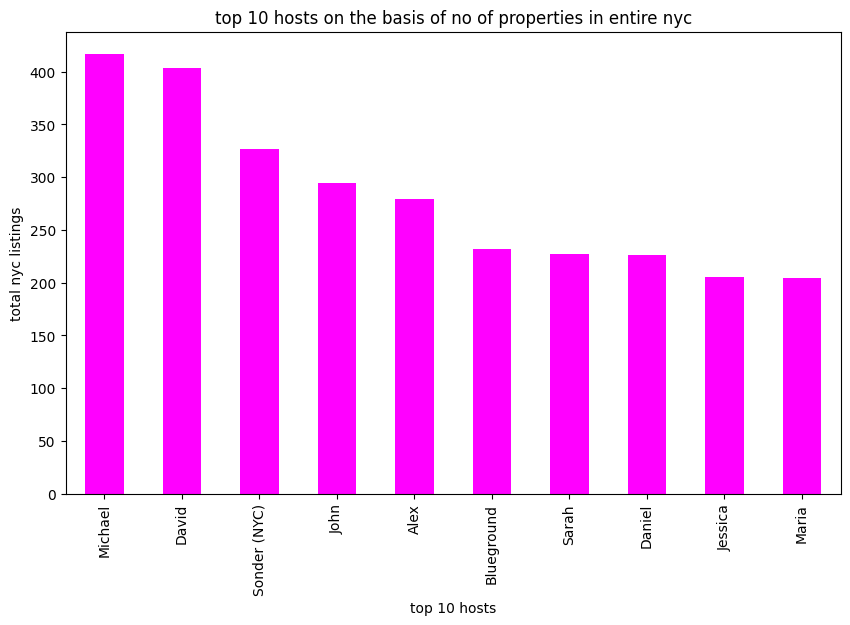

In [60]:
top_10_hosts = df['host_name'].value_counts()[:10]

top_10_hosts.plot(kind='bar', color ='magenta', figsize=(10,6))
plt.xlabel('top 10 hosts')
plt.ylabel('total nyc listings')
plt.title('top 10 hosts on the basis of no of properties in entire nyc')
plt.show()


In [61]:
# number of active hosts per location (neighbourhood group) using line chart

hosts_per_location = df.groupby('neighbourhood_group')['Property_id'].count().reset_index()
hosts_per_location.columns = ['neighbourhood_group','host_count']

In [62]:
hosts_per_location

,neighbourhood_group,host_count
0,Bronx,1091
1,Brooklyn,20104
2,Manhattan,21661
3,Queens,5666
4,Staten Island,373


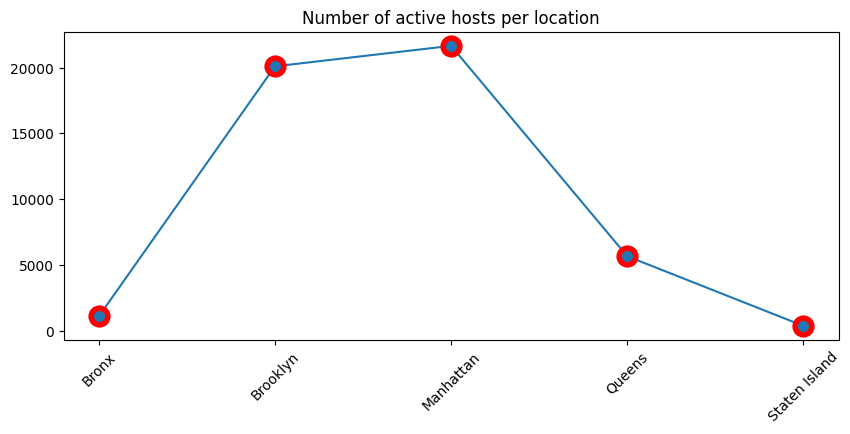

In [101]:
#locations = hosts_per_location.index
#host_counts = hosts_per_location.values

#plt.figure(figsize =(10, 4))
#plt.plot(locations , host_counts , marker ='o', ms= 12, mew=4, mec='r' )
#plt.title('number of active host per location')
#plt.show()

# Assuming after reset you have columns: 'location' and 'host_count'
locations = hosts_per_location['neighbourhood_group']
host_counts = hosts_per_location['host_count']

plt.figure(figsize=(10, 4))
plt.plot(locations, host_counts, marker='o', ms=12, mew=4, mec='r')
plt.title('Number of active hosts per location')
plt.xticks(rotation=45)
plt.show()


In [102]:
# total count of each room type

df.room_type.unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [104]:
top_room_type = df['room_type'].value_counts().reset_index()
top_room_type.columns = ['Room_type','Total_count']

In [105]:
top_room_type

,Room_type,Total_count
0,Entire home/apt,25409
1,Private room,22326
2,Shared room,1160


In [112]:
top_room_type.values

array([['Entire home/apt', 25409],
       ['Private room', 22326],
       ['Shared room', 1160]], dtype=object)

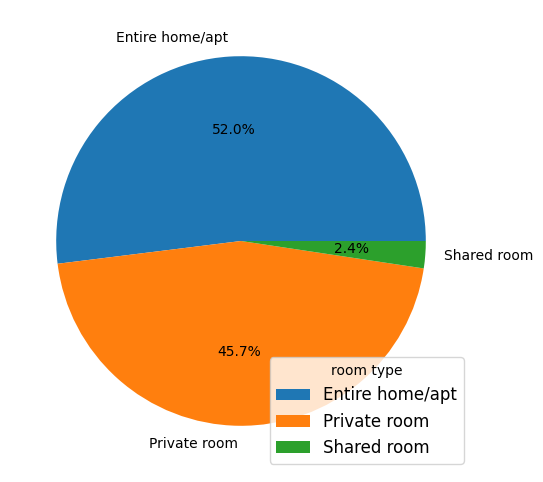

In [127]:
#plt.figure(figsize=(10,6))
#labels= top_room_type.index
#size= top_room_type.values

#plt.pie(size, labels = labels, autopct ='%1.1f%%'  ) #automatic percentage formatting
#plt.legend(title='room type', fontsize=12)
#plt.show()

top_room_type = df['room_type'].value_counts()

labels = top_room_type.index        # e.g. ['Entire home/apt', 'Private room', ...]
size = top_room_type.values         # e.g. [300, 150, 50]

plt.figure(figsize=(10,6))
plt.pie(size, labels=labels, autopct='%1.1f%%')
plt.legend(title='room type', fontsize=12)
plt.show()
